In [49]:
# ============================================================
# Cell 1. Adjustable parameters
# ============================================================

# ----------------------------
# Basic time parameters
# ----------------------------
tau = 0.96          # RC time constant, s
f = 4.0             # touch frequency, Hz
T = 1 / f           # touch period, s

t_start = 1.0       # first touch time, s
t_stop = 8       # last touch time, s
t_end = 10.0        # total simulation time, s
dt = 0.001          # time step, s

# ----------------------------
# Voltage jump parameters
# ----------------------------
# First voltage jump.
# This corresponds to:
# ΔV1 = Q_TENG / C_CR
#     ≈ (1/C_CR) * S*sigma*x_eff/(d0 + x_eff)
#
# Because this value is hard to calculate directly,
# we use an experimentally representative value.
V_first = 2.76       # V

# Coupling factor:
# beta = C_eff / C_CR
beta = 0.016         # dimensionless

# Effective pump voltage.
# To make the model consistent with ΔV1 = V_first:
# ΔV1 = beta * V_pump
# Therefore, V_pump = V_first / beta
V_pump = V_first / beta # Theoretical value
V_pump = 168            # Experimental value (Only postiive peak)

# ----------------------------
# Model options
# ----------------------------
# Case 1:
# Constant voltage increment model
# ΔVn = V_first for all n

# Case 2:
# First touch:
# ΔV1 = V_first
#
# From the second touch:
# ΔVn = beta * (V_pump - Vn_minus)
# where Vn_minus is the reservoir voltage just before n-th touch.

# ----------------------------
# Plot options
# ----------------------------
show_touch_lines = True
line_alpha = 0.4

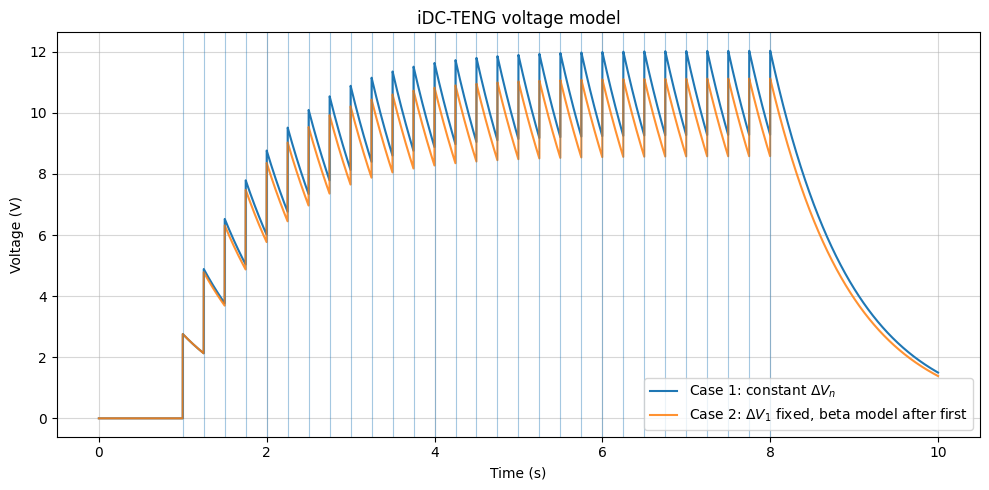

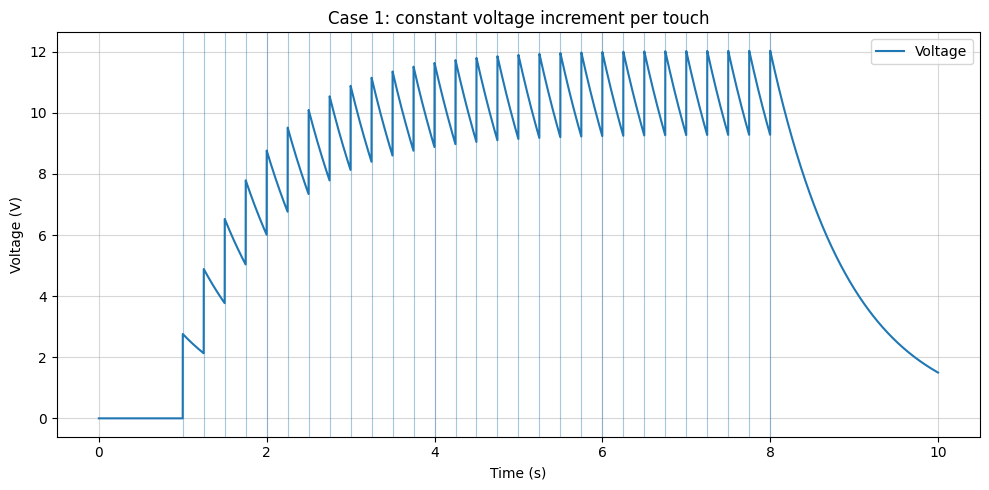

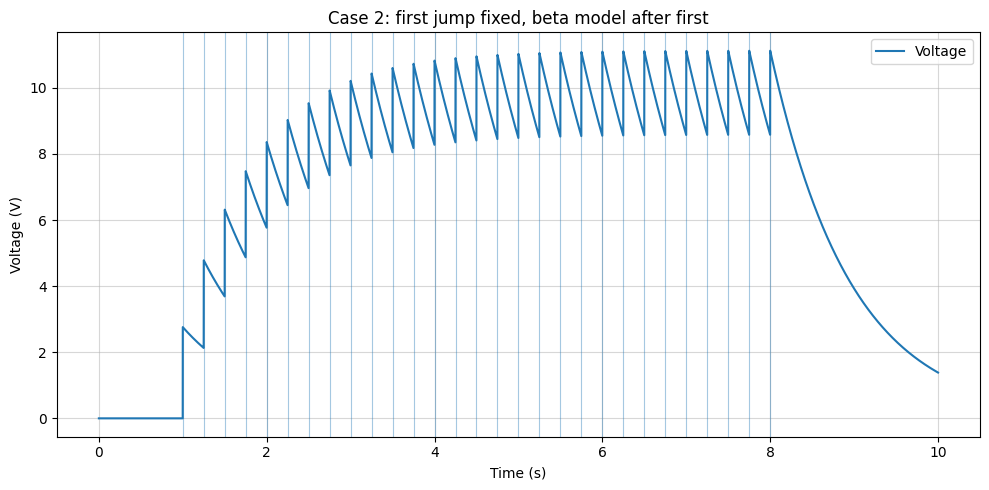

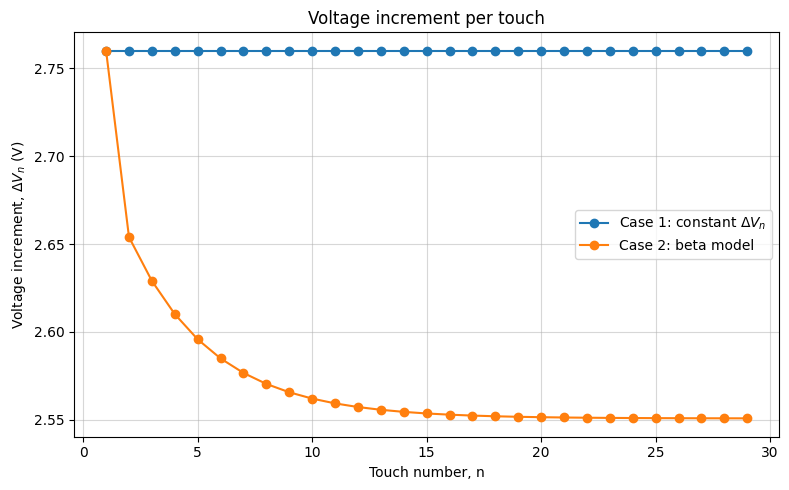

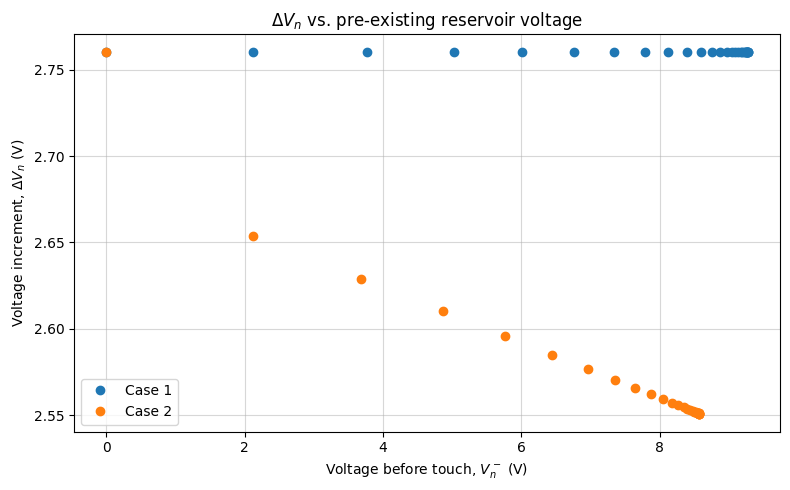

===== Simulation parameters =====
tau = 0.960 s
f = 4.000 Hz
T = 0.250 s
t_start = 1.000 s
t_stop = 8.000 s
Number of touch events = 29

===== Pump and coupling parameters =====
V_first = 2.760 V
beta = 0.016
V_pump = V_first / beta = 168.000 V

===== Case 1: constant ΔVn =====
ΔV1 = 2.760 V
ΔV2 = 2.760 V
Last ΔVn = 2.760 V
Maximum voltage before touch stop ≈ 12.030 V

===== Case 2: ΔV1 fixed, beta model after first =====
ΔV1 = 2.760 V
ΔV2 = 2.654 V
Last ΔVn = 2.551 V
Maximum voltage before touch stop ≈ 11.121 V


In [50]:
# ============================================================
# Cell 2. Calculation and plotting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Time array and touch times
# ----------------------------
t = np.arange(0, t_end + dt, dt)
touch_times = np.arange(t_start, t_stop + 1e-12, T)


# ----------------------------
# 2. Case 1: constant ΔVn
# ----------------------------
def simulate_constant_dVn(t, touch_times, tau, V_first):
    """
    Case 1: Constant voltage increment model.

    Every touch event increases the reservoir voltage by the same amount:
        ΔVn = V_first

    Between touch events, the voltage decays exponentially:
        V(t) = V0 * exp(-t/tau)
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    dV_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            # Constant voltage increment
            dV_n = V_first

            current_V += dV_n
            V_plus = current_V

            dV_list.append(dV_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(dV_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 3. Case 2: first ΔV fixed, then beta model
# ----------------------------
def simulate_beta_dVn_after_first(t, touch_times, tau, V_first, beta, V_pump):
    """
    Case 2: Voltage-dependent increment model.

    First touch:
        ΔV1 = V_first

    From the second touch:
        ΔVn = beta * (V_pump - Vn_minus),  n >= 2

    where:
        Vn_minus = reservoir voltage immediately before the n-th touch

    Physical meaning:
        V_pump is the transient pump voltage scale generated by the CP/TENG.
        Vn_minus acts as a pre-existing DC offset in the charge reservoir.
        beta = C_eff / C_CR converts the remaining driving voltage into
        the voltage increment of the charge reservoir.
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    dV_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            # Touch number: 1, 2, 3, ...
            n_touch = event_idx + 1

            if n_touch == 1:
                # First voltage jump is fixed by V_first
                dV_n = V_first
            else:
                # From second touch, use beta model
                dV_n = beta * (V_pump - V_minus)

                # Prevent negative charging
                dV_n = max(dV_n, 0.0)

            current_V += dV_n
            V_plus = current_V

            dV_list.append(dV_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(dV_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 4. Run simulations
# ----------------------------
V_const, dV_const, Vminus_const, Vplus_const = simulate_constant_dVn(
    t=t,
    touch_times=touch_times,
    tau=tau,
    V_first=V_first
)

V_beta, dV_beta, Vminus_beta, Vplus_beta = simulate_beta_dVn_after_first(
    t=t,
    touch_times=touch_times,
    tau=tau,
    V_first=V_first,
    beta=beta,
    V_pump=V_pump
)


# ----------------------------
# 5. Plot: comparison of both models
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_const, label="Case 1: constant $\\Delta V_n$")
plt.plot(t, V_beta, label="Case 2: $\\Delta V_1$ fixed, beta model after first", alpha=0.85)

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("iDC-TENG voltage model")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 6. Plot: Case 1 only
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_const, label="Voltage")

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Case 1: constant voltage increment per touch")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 7. Plot: Case 2 only
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_beta, label="Voltage")

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Case 2: first jump fixed, beta model after first")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 8. Plot: ΔVn trend
# ----------------------------
n_const = np.arange(1, len(dV_const) + 1)
n_beta = np.arange(1, len(dV_beta) + 1)

plt.figure(figsize=(8, 5))
plt.plot(n_const, dV_const, marker="o", label="Case 1: constant $\\Delta V_n$")
plt.plot(n_beta, dV_beta, marker="o", label="Case 2: beta model")

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Touch number, n")
plt.ylabel("Voltage increment, $\\Delta V_n$ (V)")
plt.title("Voltage increment per touch")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 9. Plot: ΔVn vs Vn_minus
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(Vminus_const, dV_const, marker="o", linestyle="none", label="Case 1")
plt.plot(Vminus_beta, dV_beta, marker="o", linestyle="none", label="Case 2")

plt.grid(True, which="both", alpha=0.5)

plt.xlabel("Voltage before touch, $V_n^-$ (V)")
plt.ylabel("Voltage increment, $\\Delta V_n$ (V)")
plt.title("$\\Delta V_n$ vs. pre-existing reservoir voltage")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 10. Print useful values
# ----------------------------
print("===== Simulation parameters =====")
print(f"tau = {tau:.3f} s")
print(f"f = {f:.3f} Hz")
print(f"T = {T:.3f} s")
print(f"t_start = {t_start:.3f} s")
print(f"t_stop = {t_stop:.3f} s")
print(f"Number of touch events = {len(touch_times)}")

print("\n===== Pump and coupling parameters =====")
print(f"V_first = {V_first:.3f} V")
print(f"beta = {beta:.3f}")
print(f"V_pump = V_first / beta = {V_pump:.3f} V")

print("\n===== Case 1: constant ΔVn =====")
print(f"ΔV1 = {dV_const[0]:.3f} V")
print(f"ΔV2 = {dV_const[1]:.3f} V")
print(f"Last ΔVn = {dV_const[-1]:.3f} V")
print(f"Maximum voltage before touch stop ≈ {np.max(V_const[t < t_stop]):.3f} V")

print("\n===== Case 2: ΔV1 fixed, beta model after first =====")
print(f"ΔV1 = {dV_beta[0]:.3f} V")
print(f"ΔV2 = {dV_beta[1]:.3f} V")
print(f"Last ΔVn = {dV_beta[-1]:.3f} V")
print(f"Maximum voltage before touch stop ≈ {np.max(V_beta[t < t_stop]):.3f} V")